# Importing python libraries

In [67]:
import os
import numpy as np
import librosa
from tqdm import tqdm
import ordpy
from sklearn.preprocessing import StandardScaler
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import IPython.display as ipd
from scipy.signal import correlate
from scipy.stats import mannwhitneyu

In [2]:
CLASS_DIR = 'data/human/wav/classical'
JAZZ_DIR = 'data/human/wav/jazz'

In [3]:
RANDOM_SEED  = 42
rng = np.random.default_rng(RANDOM_SEED)

# Downloading data

In [6]:
def load_audio_files(class_dir, jazz_dir, sr=16000, duration=None):
    signals = []
    labels = []
    
    class_files = [f for f in sorted(os.listdir(class_dir)) if f.endswith(".wav")]
    jazz_files = [f for f in sorted(os.listdir(jazz_dir)) if f.endswith(".wav")]
    
    for filepath in tqdm(class_files, desc="Loading classical music"):
        full_path = os.path.join(class_dir, filepath)
        y, _ = librosa.load(full_path, sr=sr, duration=duration, mono=True)
        signals.append(y)
        labels.append(0)
    
    for filepath in tqdm(jazz_files, desc="Loading jazz music"):
        full_path = os.path.join(jazz_dir, filepath)
        y, _ = librosa.load(full_path, sr=sr, duration=duration, mono=True)
        signals.append(y)
        labels.append(1)
    
    print(f"Downloaded: {labels.count(0)} classical, {labels.count(1)} jazz tracks")
    return signals, labels

In [140]:
signals, labels = load_audio_files(CLASS_DIR, JAZZ_DIR, sr=4400)

Loading jazz music: 100%|██████████| 50/50 [00:00<00:00, 275.64it/s]

Downloaded: 50 classical, 50 jazz tracks


# Computing complexity-entropy with ``ordpy``

In [ ]:
def compute_HC(signal, D, tau=1):
    try:
        H, C = ordpy.complexity_entropy(signal, dx=D, taux=tau)
        return H, C
    except Exception as e:
        print(f"Error when computing HC for dx={D}, taux={tau}: {e}")
        return None, None


def compute_HC_for_dataset(signals, D, tau=1):
    points = []
    valid_indices = []
    for i, signal in enumerate(signals):
        H, C = compute_HC(signal, D=D, tau=tau)
        if H is not None:
            points.append([H, C])
            valid_indices.append(i)
    return np.array(points), valid_indices

# Implementing Grid Search

In [ ]:
def grid_search_HC(signals, labels, dx_values=[3, 4, 5, 6, 7, 8, 9, 10], taux_values=[5, 10, 15, 20, 25]):
    results = []
    ordpy_combos = list(itertools.product(dx_values, taux_values))
    for dx, taux in tqdm(ordpy_combos, desc="ordpy params"):
        points, valid_idx = compute_HC_for_dataset(signals, D=dx, tau=taux)
        valid_labels = np.array([labels[i] for i in valid_idx])
        try:
            sil = silhouette_score(points, valid_labels)
        except:
            sil = -1
        
        try:
            lda = LinearDiscriminantAnalysis()
            lda.fit(points, valid_labels)
            lda_score = lda.score(points, valid_labels)
        except:
            lda_score = 0
        
        results.append({"dx": dx, "taux": taux, "silhouette": sil, "lda_score": lda_score, "n_valid_points": len(points)})
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("silhouette", ascending=False).reset_index(drop=True)
    return results_df

In [10]:
results_df = grid_search_HC(signals, labels)

ordpy params: 100%|██████████| 40/40 [15:08<00:00, 22.72s/it]


In [11]:
results_df.to_csv("grid_search_results_genre.csv", index=False)

In [12]:
results_df.head(20)

,dx,taux,silhouette,lda_score,n_valid_points
0,9,5,0.174984,0.73,100
1,7,25,0.168325,0.68,100
2,8,25,0.165819,0.69,100
3,8,15,0.165201,0.77,100
4,9,25,0.162336,0.71,100
5,9,10,0.162141,0.73,100
6,10,5,0.159441,0.72,100
7,8,5,0.158559,0.72,100
8,6,25,0.155110,0.69,100
9,9,15,0.154964,0.76,100


> D = 9, tau = 5

In [70]:
D = 9
tau = 5

In [71]:
points, valid_idx = compute_HC_for_dataset(signals, D=D, tau=tau)
valid_labels = [labels[i] for i in valid_idx]

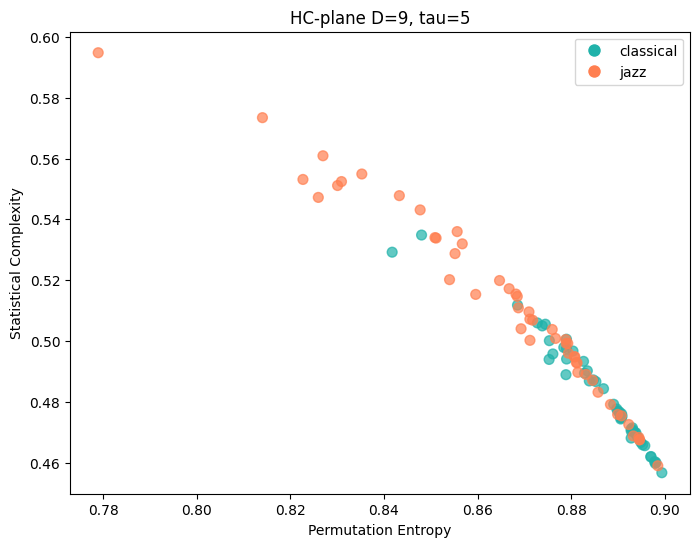

In [72]:
colors = ["lightseagreen" if l == 0 else "coral" for l in valid_labels]

plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], c=colors, alpha=0.7, s=50)
plt.xlabel("Permutation Entropy")
plt.ylabel("Statistical Complexity")
plt.title(f"HC-plane D={D}, tau={tau}")
plt.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='lightseagreen', markersize=10, label='classical'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='coral', markersize=10, label='jazz')
])
plt.show()

In [ ]:
H_classical = points[:50, 0]
C_classical = points[:50, 1]
H_jazz = points[50:, 0]
C_jazz = points[50:, 1]

print(f"Classical: median H = {np.median(H_classical):.4f}, median C = {np.median(C_classical):.4f}")
print(f"Jazz: median H = {np.median(H_jazz):.4f}, median C = {np.median(C_jazz):.4f}")

stat_H, p_H = mannwhitneyu(H_classical, H_jazz, alternative='two-sided')
print(f"Mann-Whitney H: p = {p_H:.4f}")

stat_C, p_C = mannwhitneyu(C_classical, C_jazz, alternative='two-sided')
print(f"Mann-Whitney C: p = {p_C:.4f}")

Classical: median H = 0.8902, median C = 0.4769
Jazz: median H = 0.8712, median C = 0.5055
Mann-Whitney H: p = 0.0000
Mann-Whitney C: p = 0.0000


# Подбор гиперпараметров для вычисления фрактальной размерности

## FNN rate (подбор dimension embedding)

In [16]:
from scipy.signal import correlate
from scipy.spatial import KDTree
from collections import defaultdict

FFN rate (алгоритм):
1. реконструируем фазовое пространсво для d и d + 1
2. ищем ближайшего соседа в d-мерном пространстве
3. ищем расстояние до того же соседа [индекса] в (d + 1)-мерном пространстве
4. считаем относительное изменение расстояния
5. считает false nearest neighboor как среднее всех относительных изменений, которые выросли в 10 раз


In [ ]:
def embed(signal, d, tau):
    N = len(signal) - (d - 1) * tau
    return np.stack([signal[i * tau: i * tau + N] for i in range(d)], axis=1)

def fnn_rate(signal, d_max=10, tau=1, rtol= 15.0, sample=10_000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)

    rates = []
    for d in range(1, d_max + 1):
        Y_d, Y_d1 = embed(signal, d, tau), embed(signal, d + 1, tau)
        n = min(len(Y_d), len(Y_d1), sample)
        idx = rng.choice(min(len(Y_d), len(Y_d1)), size=n, replace=False)
        Yd = Y_d[idx]
        Yd1 = Y_d1[idx]

        tree = KDTree(Yd)
        dists, nn_idx = tree.query(Yd, k=2)
        r_d, nn = dists[:, 1], nn_idx[:, 1]
        r_d1 = np.linalg.norm(Yd1 - Yd1[nn], axis=1)

        safe = r_d > 1e-10
        ratio = np.zeros(n)
        ratio[safe] = np.abs(r_d1[safe] - r_d[safe]) / r_d[safe]

        fnn = np.mean(ratio > rtol)
        rates.append(fnn)

    return np.array(rates)

In [ ]:
FNN_SAMPLE = 10_000
FNN_D_MAX = 10
FNN_RTOL = 10.0
FNN_TAU = 6

In [ ]:
class_rates = defaultdict(list)
class_dopt = defaultdict(list)

for sig, lbl in tqdm(zip(signals, labels), total=len(signals), desc='FNN'):
    sig = np.array(sig, dtype=np.float64)
    if len(sig) > FNN_SAMPLE:
        start = rng.integers(0, len(sig) - FNN_SAMPLE)
        sig_sub = sig[start: start + FNN_SAMPLE]
    else:
        sig_sub = sig

    rates = fnn_rate(sig_sub, d_max=FNN_D_MAX, tau=FNN_TAU, rtol=FNN_RTOL, rng=rng)

    below = np.where(rates < 0.01)[0]
    D_opt = int(below[0]) + 1 if len(below) > 0 else FNN_D_MAX

    class_rates[lbl].append(rates)
    class_dopt[lbl].append(D_opt)

FNN: 100%|██████████| 100/100 [00:39<00:00,  2.53it/s]


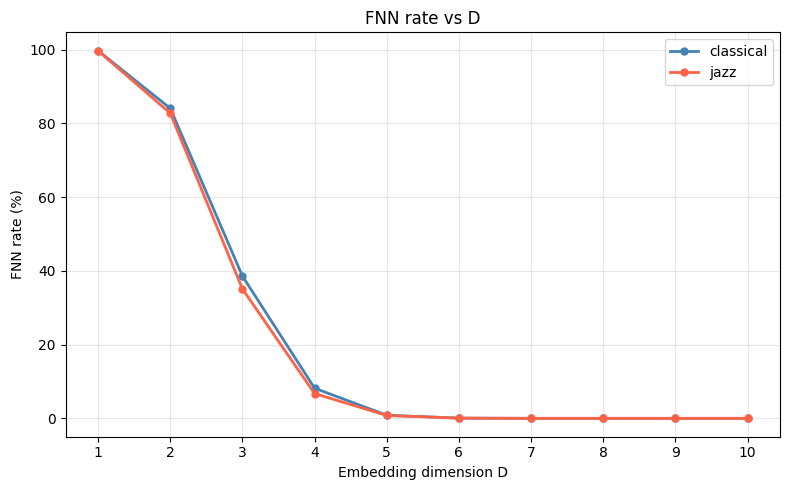

In [ ]:
colors  = {lbl: c for lbl, c in zip(sorted(class_rates.keys()), ['steelblue', 'tomato'])}
d_range = np.arange(1, FNN_D_MAX + 1)

fig, ax = plt.subplots(figsize=(8, 5))
for lbl, rate_list in sorted(class_rates.items()):
    mat = np.array(rate_list) * 100
    med = np.median(mat, axis=0)
    c = colors[lbl]
    ax.plot(d_range, med, marker='o', ms=5, lw=2, color=c, label=f'{'classical' if lbl == 0 else 'jazz'}')
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('FNN rate (%)')
ax.set_title(f'FNN rate vs D')
ax.set_xticks(d_range)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> $D^* = 5$ для обоих классов

## ACF для tau

In [21]:
MAX_TAU = 15

In [22]:
def compute_acf(signal, tau_max):
    x = signal - signal.mean()
    full = correlate(x, x, mode='full')
    mid  = len(full) // 2
    acf  = full[mid:mid + tau_max + 1]
    acf /= acf[0]
    return acf

def first_zero_crossing(acf):
    for i in range(1, len(acf)):
        if acf[i] <= 0.0:
            t = i - 1 + acf[i-1] / (acf[i-1] - acf[i])
            return int(round(t))
    return len(acf) - 1

In [ ]:
class_acf  = defaultdict(list)
class_taus = defaultdict(list)

for sig, lbl in tqdm(zip(signals, labels), total=len(signals), desc='ACF'):
    sig = np.array(sig, dtype=np.float64)
    acf = compute_acf(sig, MAX_TAU)
    tau = first_zero_crossing(acf)
    class_acf[lbl].append(acf)
    class_taus[lbl].append(tau)

ACF: 100%|██████████| 100/100 [00:00<00:00, 161.41it/s]


In [40]:
def first_zero(curve: np.ndarray) -> int:
    for i in range(1, len(curve) - 1):
        if curve[i-1] > 0 and curve[i] <= 0:
            return i
    return int(np.argmin(curve))

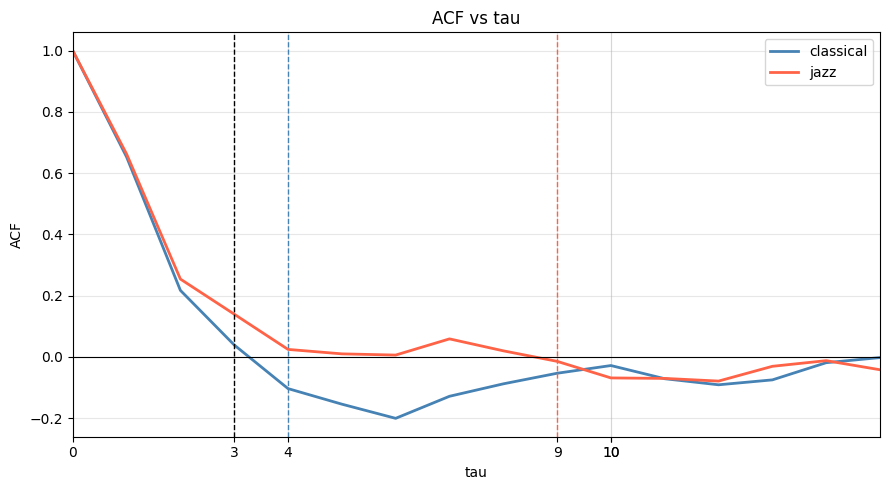

In [ ]:
colors  = {lbl: c for lbl, c in zip(sorted(class_acf.keys()), ['steelblue', 'tomato'])}
lags = np.arange(0, MAX_TAU + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, acf_list in sorted(class_acf.items()):
    mat = np.array(acf_list)
    med = np.median(mat, axis=0)
    tau_acf = first_zero(med)
    c = colors[lbl]
    ax.plot(lags, med, lw=2, color=c, label=f'{'classical' if lbl == 0 else 'jazz'}')
    ax.axvline(tau_acf, color=c, ls='--', lw=1)
ax.axvline(3, color='black', ls='--', lw=1)
ax.axhline(0,  color='black',  lw=0.8)
ax.set_xlabel('tau')
ax.set_ylabel('ACF')
ax.set_title(f'ACF vs tau')
ax.set_xlim(0, 15)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(list(range(0, MAX_TAU + 1, 10))+ [3, 4, 9, 10])
plt.tight_layout()
plt.show()

## MI для tau

In [25]:
N_BINS  = 64
TAU_MAX = 15

In [26]:
def compute_mi_curve(signal, tau_max, n_bins):
    vmin, vmax = signal.min(), signal.max()
    edges = np.linspace(vmin, vmax, n_bins + 1)

    mi_vals = []
    for tau in range(1, tau_max + 1):
        x = signal[:-tau]
        y = signal[tau:]
        joint, _, _ = np.histogram2d(x, y, bins=[edges, edges])
        joint = joint / joint.sum()

        px = joint.sum(axis=1)
        py = joint.sum(axis=0)
        denom = np.outer(px, py)
        denom[denom == 0] = 1e-12

        mask = joint > 0
        mi = (joint[mask] * np.log2(joint[mask] / denom[mask])).sum()
        mi_vals.append(max(mi, 0.0))

    return np.array(mi_vals)


def first_local_min(curve: np.ndarray) -> int:
    for i in range(1, len(curve) - 1):
        if curve[i] < curve[i-1] and curve[i] < curve[i+1]:
            return i + 1
    return int(np.argmin(curve)) + 1

In [ ]:
class_mi = defaultdict(list)
class_taus_mi = defaultdict(list)

for sig, lbl in tqdm(zip(signals, labels), total=len(signals), desc='MI'):
    sig = np.array(sig, dtype=np.float64)
    mi_cur = compute_mi_curve(sig, TAU_MAX, N_BINS)
    tau_mi = first_local_min(mi_cur)
    class_mi[lbl].append(mi_cur)
    class_taus_mi[lbl].append(tau_mi)

MI: 100%|██████████| 100/100 [00:07<00:00, 13.12it/s]


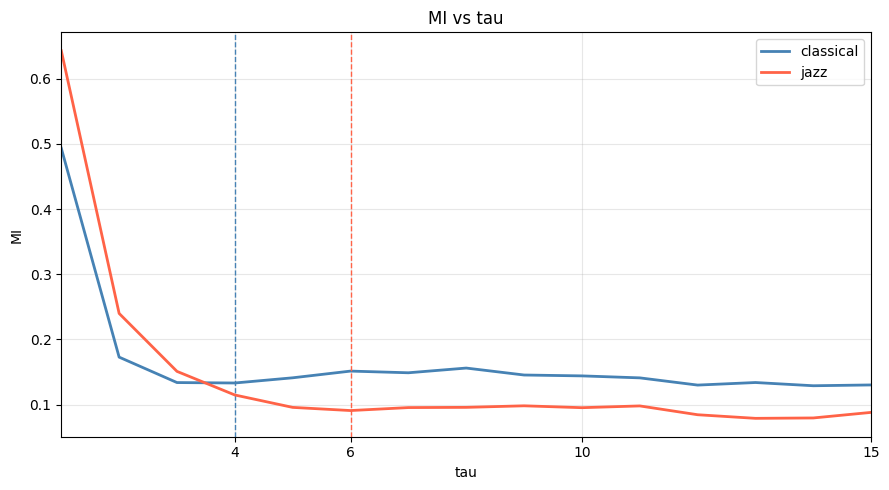

In [ ]:
colors  = {lbl: c for lbl, c in zip(sorted(class_mi.keys()), ['steelblue', 'tomato'])}
mi_lags = np.arange(1, TAU_MAX + 1)

fig, ax = plt.subplots(figsize=(9, 5))
for lbl, mi_list in sorted(class_mi.items()):
    mat = np.array(mi_list)
    med = np.median(mat, axis=0)
    tau_med_curve = first_local_min(med)
    c = colors[lbl]
    ax.plot(mi_lags, med, lw=2, color=c, label=f'{'classical' if lbl == 0 else 'jazz'}')
    ax.axvline(tau_med_curve, color=c, ls='--', lw=1)
ax.set_xlabel('tau')
ax.set_ylabel('MI')
ax.set_title(f'MI vs tau')
ax.set_xlim(1, 15)
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks([4, 6, 10, 15])
plt.tight_layout()
plt.show()

> tau = 6

# Фрактальные размерности

## Алгоритм Швайнхарта

In [46]:
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [47]:
def reconstruct_signal(signal, tau, D):
    length = len(signal)
    rec_signal_length = length - (D - 1) * tau
    return np.array([signal[i:i + D * tau:tau] for i in range(rec_signal_length)])

In [50]:
def mst_edge_weights(points):
    dist_matrix = cdist(points, points, metric='euclidean')
    mst = minimum_spanning_tree(dist_matrix)
    return mst.data

def compute_E_alpha(edge_weights, alpha_values):
    return np.array([np.sum(edge_weights ** alpha) for alpha in alpha_values])

In [ ]:
rng = np.random.default_rng(seed=42)

alpha_values = np.arange(1.0, 8.1, 0.2)

size_grid = np.unique(np.round(np.logspace(np.log10(200), np.log10(2000), 10)).astype(int))

n_repeats = 5
size_grid

array([ 200,  258,  334,  431,  557,  719,  928, 1199, 1549, 2000])

In [ ]:
def fit_regression(size_grid, E_values, alpha):
    ln_size = np.log(size_grid.astype(float))
    ln_E = np.log(E_values)
    slope, _, _, _, se_slope = stats.linregress(ln_size, ln_E)
    beta = slope
    if beta <= 0 or beta >= 1:
        return dict(d_hat=np.nan, beta=beta, valid=False)
    d_hat = alpha / (1.0 - beta)
    n = len(ln_size)
    t_crit = stats.t.ppf(0.975, df=n - 2)
    ci_beta = t_crit * se_slope
    gamma = 0.10
    rel_ci = ci_beta / (abs(beta) + 1e-9)
    valid = rel_ci <= gamma
    return dict(d_hat=d_hat, beta=beta, rel_ci=rel_ci, valid=valid)

In [ ]:
TAU = 6
schw_medians = {}

for D in range(5, 16):
    reconstructed_signals = []
    for signal in signals:
        emb = reconstruct_signal(signal, TAU, D)
        reconstructed_signals.append(emb)
    E_matrices = []
    for track_idx, emb in enumerate(tqdm(reconstructed_signals, desc="треки")):
        E_matrix = np.zeros((len(alpha_values), len(size_grid)))
        for j, size in enumerate(size_grid):
            E_per_repeat = np.zeros((n_repeats, len(alpha_values)))
            for r in range(n_repeats):
                idx = rng.choice(len(emb), size=size, replace=False)
                pts = emb[idx]
                edge_weights = mst_edge_weights(pts)
                E_per_repeat[r] = compute_E_alpha(edge_weights, alpha_values)
            E_matrix[:, j] = E_per_repeat.mean(axis=0)
        E_matrices.append(E_matrix)
    results = []
    for track_idx, E_matrix in enumerate(tqdm(E_matrices, desc="треки")):
        valid_d_hats = []
        for a_idx, alpha in enumerate(alpha_values):
            E_values = E_matrix[a_idx, :]
            mask = (E_values > 0) & np.isfinite(E_values)
            if mask.sum() < 3:
                continue
            res = fit_regression(size_grid[mask], E_values[mask], alpha)
            if res['valid'] and np.isfinite(res['d_hat']) and res['d_hat'] > 0:
                valid_d_hats.append(res['d_hat'])
        if len(valid_d_hats) == 0:
            d_median = np.nan
        else:
            d_median = np.median(valid_d_hats)
        results.append(dict(track_idx=track_idx, label=labels[track_idx], n_valid_alpha=len(valid_d_hats), d_median=d_median))

    results_df = pd.DataFrame(results)
    labels_unique = results_df['label'].unique()

    group1 = results_df[results_df['label'] == labels_unique[0]]['d_median'].dropna()
    group2 = results_df[results_df['label'] == labels_unique[1]]['d_median'].dropna()

    stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
    print(f"D={D}: Mann-Whitney p = {p:.4f}")
    print(results_df.groupby('label')['d_median'].median())

    schw_medians[D] = {labels_unique[0]: group1.median(), labels_unique[1]: group2.median()}

треки: 100%|██████████| 100/100 [00:00<00:00, 204.29it/s]


D=5: Mann-Whitney p = 0.0000
label
0    5.605737
1    5.323834
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 197.30it/s]


D=6: Mann-Whitney p = 0.0000
label
0    6.619490
1    6.191608
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 199.51it/s]


...

D=13: Mann-Whitney p = 0.0000
label
0    11.987441
1     9.434442
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 177.56it/s]


D=14: Mann-Whitney p = 0.0000
label
0    12.251301
1     9.637844
Name: d_median, dtype: float64


треки: 100%|██████████| 100/100 [00:00<00:00, 178.49it/s]

D=15: Mann-Whitney p = 0.0000
label
0    12.527252
1     9.751202
Name: d_median, dtype: float64


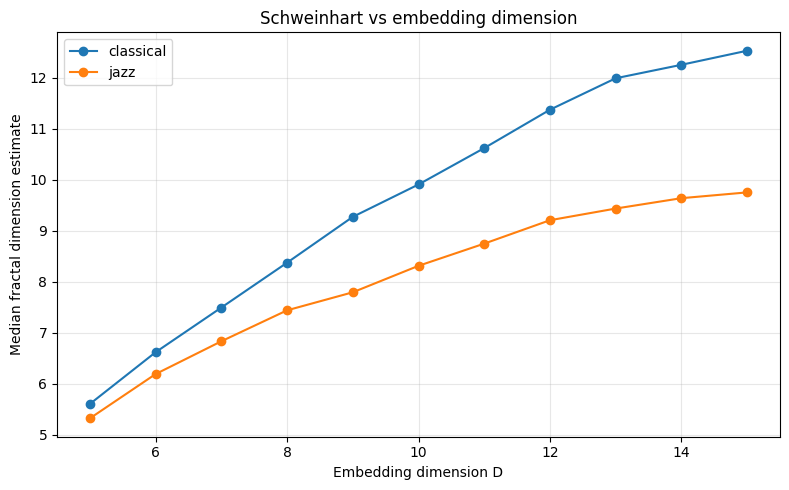

In [ ]:
D_values = list(schw_medians.keys())
label_names = list(schw_medians[D_values[0]].keys())
labels= ['classical', 'jazz']

fig, ax = plt.subplots(figsize=(8, 5))
for j, label in enumerate(label_names):
    medians = [schw_medians[D][label] for D in D_values]
    ax.plot(D_values, medians, marker='o', label=labels[j])
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('Median fractal dimension estimate')
ax.set_title('Schweinhart vs embedding dimension')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Алгоритм MLE

In [ ]:
def compute_mle_dim(signal, D=10, tau=20, n_samples=2000, k=10, random_seed=42):
    vectors = reconstruct_signal(signal, tau, D)
    rng = np.random.default_rng(random_seed)
    idx = rng.choice(len(vectors), size=n_samples, replace=False)
    sample = vectors[idx]
    tree = KDTree(sample)
    distances, _ = tree.query(sample, k=k + 1)
    dists = distances[:, 1:]

    T_k = dists[:, -1]
    T_j = dists[:, :-1]

    eps = 1e-10
    T_k_safe = np.maximum(T_k[:, np.newaxis], eps)
    T_j_safe = np.maximum(T_j, eps)
    log_ratios = np.log(T_k_safe / T_j_safe)
    mean_log = np.mean(log_ratios, axis=1)
    valid = mean_log > eps
    if valid.sum() == 0:
        return np.nan
    m_hat = 1.0 / mean_log[valid]
    return float(np.median(m_hat))

In [ ]:
def analyze_mle_dim(signals, labels, D=10, tau=20, n_samples=2000, k=10):
    results = []
    for i, (sig, label) in enumerate(zip(signals, labels)):
        mle = compute_mle_dim(sig, D=D, tau=tau, n_samples=n_samples, k=k)
        results.append({'track': i, 'label': label, 'mle_dim': mle})
    df = pd.DataFrame(results)
    print(f"Параметры: D={D}, tau={tau}, n_samples={n_samples}, k={k}\n")
    summary = df.groupby('label')['mle_dim'].agg(['median', 'mean', 'std'])
    print("По классам:")
    print(summary.round(3))
    return {'per_track': df, 'summary': summary}

In [ ]:
TAU = 6

mle_medians = {}
mle_results_0 = []
mle_results_1 = []

for D in range(5, 16):
    df = analyze_mle_dim(signals, labels, D=D, tau=TAU)['per_track']
    group0 = df[df['label'] == 0]['mle_dim'].dropna()
    group1 = df[df['label'] == 1]['mle_dim'].dropna()
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    print(f"D={D}: Mann-Whitney p = {p:.4f}")
    print(df.groupby('label')['mle_dim'].median())
    mle_results_0.append(group0)
    mle_results_1.append(group1)
    mle_medians[D] = {0: group0.median(), 1: group1.median()}

Параметры: D=5, tau=6, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       5.375  5.365  0.089
1       5.183  5.169  0.200
D=5: Mann-Whitney p = 0.0000
label
0    5.375138
1    5.183334
Name: mle_dim, dtype: float64
Параметры: D=6, tau=6, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       6.382  6.373  0.164
1       6.075  6.013  0.364
D=6: Mann-Whitney p = 0.0000
label
0    6.382351
1    6.075029
Name: mle_dim, dtype: float64
Параметры: D=7, tau=6, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       7.278  7.275  0.253
1       6.841  6.746  0.548
D=7: Mann-Whitney p = 0.0000
label
0    7.278031
1    6.840935
Name: mle_dim, dtype: float64
Параметры: D=8, tau=6, n_samples=2000, k=10

По классам:
       median   mean    std
label                      
0       8.162  8.159  0.311
1       7.526  7.395  0.742
D=8: Mann-Whitney p = 0.0000
label
0    8.162

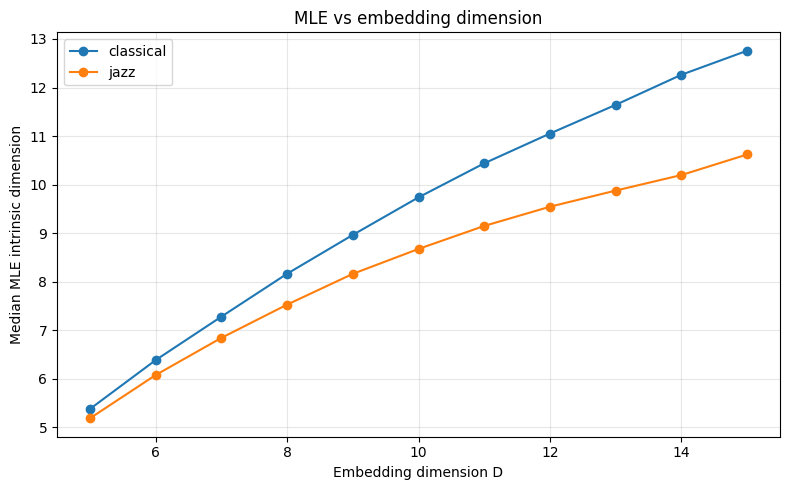

In [ ]:
D_values = list(mle_medians.keys())

fig, ax = plt.subplots(figsize=(8, 5))
for label, name in [(0, 'classical'), (1, 'jazz')]:
    medians = [mle_medians[D][label] for D in D_values]
    ax.plot(D_values, medians, marker='o', label=name)
ax.set_xlabel('Embedding dimension D')
ax.set_ylabel('Median MLE intrinsic dimension')
ax.set_title('MLE vs embedding dimension')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()